# Figure 3b

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [2]:
#3 Alpha clusters, 2 Delta clusters and 1 Delta singleton , and 8 Omicron clusters and 8 Omicron singleton

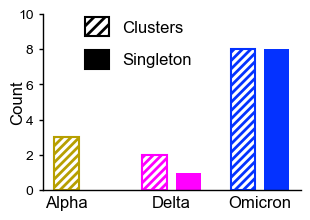

In [6]:

# Make output match the shown style regardless of any active notebook style
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["hatch.linewidth"] = 2.0
mpl.rcParams["axes.linewidth"] = 1.0

# Data
variants   = ["Alpha", "Delta", "Omicron"]
clusters   = np.array([3, 2, 8])
singletons = np.array([0, 1, 8])

# Colors sampled from the figure
colors = ["#B79F00", "magenta", "#0432FF"]

x = np.arange(len(variants))
width = 0.28
mpl.rcParams["font.family"] = "Arial"
fig, ax = plt.subplots(figsize=(3.0, 2.35), dpi=100)

gap = 0.05  # tweak (0.02–0.10)

# Clusters (hatched, white fill)
for xi, h, c in zip(x, clusters, colors):
    ax.bar(
        xi - (width/2 + gap), h, width=width,
        facecolor="white", edgecolor=c, linewidth=1.5,
        hatch="////"
    )

# Singletons (solid)
for xi, h, c in zip(x, singletons, colors):
    if h == 0:
        continue
    ax.bar(
        xi + (width/2 + gap), h, width=width,
        color=c, edgecolor="none", linewidth=0
    )

# Axes formatting
tick_pos = x.astype(float).copy()
tick_pos[0] = x[0] - (width/2 + gap)   # Alpha label centered on the cluster bar JUST FOR ALPHA
ax.set_xticks(tick_pos)
ax.set_xticklabels(variants, fontsize=12)

ax.set_ylabel("Count", fontsize=12,labelpad=-5)
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0, 11, 2))

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=3, width=1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend (as shown: generic black/white handles)
legend_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="///", linewidth=1.5, label="Clusters"),
    Patch(facecolor="black", edgecolor="black", linewidth=1.5, label="Singleton"),
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.14, 1.02),
    frameon=False,
    borderaxespad=0.0,
    handlelength=1.4,
    handleheight=1.4,
    labelspacing=0.8,
    fontsize=12
)

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.20, top=0.95)

plt.savefig('Fig2b.png',format='png',
           dpi=1000,bbox_inches='tight')
plt.show()

# Figure 3c

In [1]:
import pandas as pd

In [2]:
tableS2_clusters = pd.read_csv("01_TableS2_clusters in fig2a.csv")
tableS2_clusters

,cluster_number,tip_name,variant,cluster_type
0,1,23-031606-079_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster
1,1,23-031606-068_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster
2,1,23-031606-066_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster
3,1,23-031606-065_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster
4,1,23-031606-063_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster
...,...,...,...,...
97,21,23-031606-131_PA_Crawford_2022-11-28_B.1.1.7,alpha,cluster
98,22,23-031606-106_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster
99,22,23-031606-105_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster
100,22,23-031606-103_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster


In [3]:
tableS2_clusters['State'] = [split_val.split('_')[1] for split_val in tableS2_clusters.tip_name.values]
tableS2_clusters['County'] = [split_val.split('_')[2] for split_val in tableS2_clusters.tip_name.values]
tableS2_clusters

,cluster_number,tip_name,variant,cluster_type,State,County
0,1,23-031606-079_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster,PA,Philadelphia
1,1,23-031606-068_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster,PA,Philadelphia
2,1,23-031606-066_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster,PA,Philadelphia
3,1,23-031606-065_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster,PA,Philadelphia
4,1,23-031606-063_PA_Philadelphia_2022-12-22_BA.5.1,omicron,cluster,PA,Philadelphia
...,...,...,...,...,...,...
97,21,23-031606-131_PA_Crawford_2022-11-28_B.1.1.7,alpha,cluster,PA,Crawford
98,22,23-031606-106_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster,PA,Warren
99,22,23-031606-105_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster,PA,Warren
100,22,23-031606-103_PA_Warren_2022-11-28_B.1.1.7,alpha,cluster,PA,Warren


In [17]:
#tableS2_clusters.to_csv('02_county_TableS2_clusters in fig2a.csv',index=False)

<ipython-input-4-91fc1038e819>:88: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Cluster', 'Singleton'], fontsize=11)
<ipython-input-4-91fc1038e819>:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([s.split(":")[1] for s in ycat_order], fontsize=16)


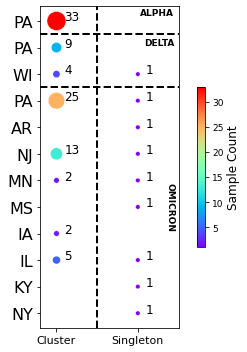

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Load and clean data
df = pd.read_csv("02_county_TableS2_clusters in fig2a.csv")
df["State"] = df["State"].str.strip()
df["cluster_type"] = df["cluster_type"].str.strip()
df["variant"] = df["variant"].str.strip()

# Make unique state list for each variant, preserving order
variant_order = ['alpha', 'delta', 'omicron']
variant_state_order = []
for v in variant_order:
    states = df.loc[df['variant'] == v, 'State']
    variant_state_order.extend([f"{v}:{s}" for s in states])

seen = set()
ycat_order = []
for s in variant_state_order:
    if s not in seen:
        ycat_order.append(s)
        seen.add(s)

# Combine variant and state into one field
df["ycat"] = df["variant"].astype(str) + ":" + df["State"]

# Group for plotting
grouped = df.groupby(["ycat", "cluster_type"]).size().reset_index(name="count")
grouped['variant'] = grouped['ycat'].apply(lambda x: x.split(':')[0])
grouped['State'] = grouped['ycat'].apply(lambda x: x.split(':')[1])

# Convert to ordered categories
grouped["ycat"] = pd.Categorical(grouped["ycat"], categories=ycat_order, ordered=True)
grouped["cluster_type"] = pd.Categorical(grouped["cluster_type"], categories=["cluster", "singleton"], ordered=True)

# Plot
plt.figure(figsize=(3.5, 5))
chosen_pal = 'rainbow'
ax = sns.scatterplot(
    data=grouped,
    x='cluster_type', y='ycat',
    size='count', hue='count',
    sizes=(20, 360), palette=chosen_pal, legend=False
)

# Colorbar
norm = Normalize(vmin=grouped['count'].min(), vmax=grouped['count'].max())
sm = ScalarMappable(cmap=chosen_pal, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1,shrink=0.5)
cbar.set_label("Sample Count",fontsize=12)
cbar.ax.tick_params(labelsize=9)
# Bubble count annotations
for _, row in grouped.iterrows():
    x = 0 if row['cluster_type'] == 'cluster' else 1
    y = ycat_order.index(row['ycat'])
    ax.text(x + 0.1, y - 0.15, str(row['count']), va='center', ha='left', fontsize=12)

# Dashed line to separate cluster/singleton
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
#ax.axvline(x=1.34, color='black', linestyle='-', linewidth=1)

# Draw horizontal lines between variant groups and add variant labels
hpos = 0
for v in variant_order:
    count = sum([s.startswith(v + ":") for s in ycat_order])
    if count > 0:
        if hpos > 0:
            ax.axhline(hpos - 0.5, color='black', linestyle='--', linewidth=2)
        mid = hpos + count / 2 - 0.5
        if v.upper()=='ALPHA':
            ax.text(0.97, mid-0.3, v.upper(), va='center', ha='right',
                fontsize=9, fontweight='bold', transform=ax.get_yaxis_transform())
        elif v.upper()=='DELTA':
            ax.text(0.97, mid-0.7, v.upper(), va='center', ha='right',
                fontsize=9, fontweight='bold', transform=ax.get_yaxis_transform())
        else:
            ax.text(0.97, mid-0.01, v.upper(), va='center', ha='right',rotation=-90,
                fontsize=9, fontweight='bold', transform=ax.get_yaxis_transform())
        hpos += count

# Final label tweaks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(['Cluster', 'Singleton'], fontsize=11)
ax.set_yticklabels([s.split(":")[1] for s in ycat_order], fontsize=16)
plt.xlim(-0.2, 1.5)
plt.tight_layout()
plt.savefig('bubble_plot_variants_cluster.png',format='png',
           dpi=1000,bbox_inches='tight')
